In [1]:
import sys

project_root = '/Users/aaronluenendonk/movie-sentiment-analysis'
if project_root not in sys.path:
    sys.path.append(project_root)

import nltk
nltk.download('stopwords')
import random
import numpy as np
from nltk.corpus import movie_reviews
from sklearn.metrics import accuracy_score, classification_report

# Modular imports from the architecture
from src.preprocessing import process_movie_review
from src.features import build_freqs, extract_features
from src.model import gradient_descent, predict
import nltk
import random
import numpy as np
from nltk.corpus import movie_reviews
from sklearn.metrics import accuracy_score, classification_report

# Modular imports from the architecture
from src.preprocessing import process_movie_review
from src.features import build_freqs, extract_features
from src.model import gradient_descent, predict

# 1. Loading and formatting data
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.seed(42)
random.shuffle(documents)

# 2. Extract X (features) and Y (labels)
X_raw = [doc for doc, cat in documents]
Y = np.array([1 if cat == 'pos' else 0 for doc, cat in documents])

# 3. Apply preprocessing
X_processed = [process_movie_review(tokens) for tokens in X_raw]

# 4. Train-Test Split (80/20)
split = int(len(X_processed) * 0.8)
X_train_raw, X_test_raw = X_processed[:split], X_processed[split:]
Y_train, Y_test = Y[:split], Y[split:]

# 5. Build a frequency dictionary (using training data only!)
freqs = build_freqs(X_train_raw, Y_train)

# 6. Feature extraction (conversion to numerical vectors)
X_train = np.array([extract_features(tokens, freqs) for tokens in X_train_raw])
X_test = np.array([extract_features(tokens, freqs) for tokens in X_test_raw])

# Standardise the features so that they all have the same influence.
# Exclude column 0 (the bias), as this always remains 1.
mean_features = np.mean(X_train[:, 1:], axis=0)
std_features = np.std(X_train[:, 1:], axis=0)
std_features[std_features == 0] = 1 # Prevents division by zero

X_train_norm = np.copy(X_train)
X_test_norm = np.copy(X_test)

X_train_norm[:, 1:] = (X_train[:, 1:] - mean_features) / std_features
X_test_norm[:, 1:] = (X_test[:, 1:] - mean_features) / std_features

# 7. Train the model
# Thanks to normalisation, alpha can be increased from 1e-9 to 0.1!
trained_weight, cost_history = gradient_descent(X_train_norm, Y_train, alpha=0.1, num_iters=1500)

# 8. Evaluation
y_pred = predict(X_test_norm, trained_weight)
accuracy = np.mean(y_pred == Y_test)

print(f"Accuracy of custom logistic regression: {accuracy*100:.2f}%")
print(classification_report(Y_test, y_pred, target_names=['negativ', 'positiv']))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aaronluenendonk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Epoch    0 | Loss: 0.6931
Epoch  100 | Loss: 0.6618
Epoch  200 | Loss: 0.6493
Epoch  300 | Loss: 0.6373
Epoch  400 | Loss: 0.6258
Epoch  500 | Loss: 0.6148
Epoch  600 | Loss: 0.6042
Epoch  700 | Loss: 0.5941
Epoch  800 | Loss: 0.5844
Epoch  900 | Loss: 0.5751
Epoch 1000 | Loss: 0.5661
Epoch 1100 | Loss: 0.5575
Epoch 1200 | Loss: 0.5493
Epoch 1300 | Loss: 0.5413
Epoch 1400 | Loss: 0.5337
Accuracy of custom logistic regression: 67.00%
              precision    recall  f1-score   support

     negativ       0.64      0.77      0.70       198
     positiv       0.72      0.57      0.64       202

    accuracy                           0.67       400
   macro avg       0.68      0.67      0.67       400
weighted avg       0.68      0.67      0.67       400



Image saved at: /Users/aaronluenendonk/movie-sentiment-analysis/images/wordcloud_positive.png


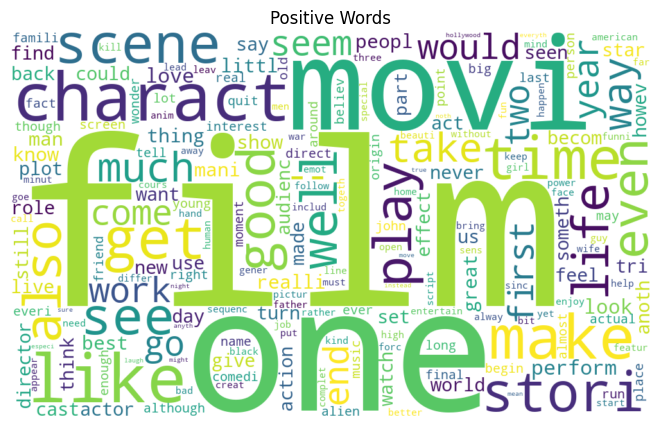

Image saved at: /Users/aaronluenendonk/movie-sentiment-analysis/images/wordcloud_negative.png


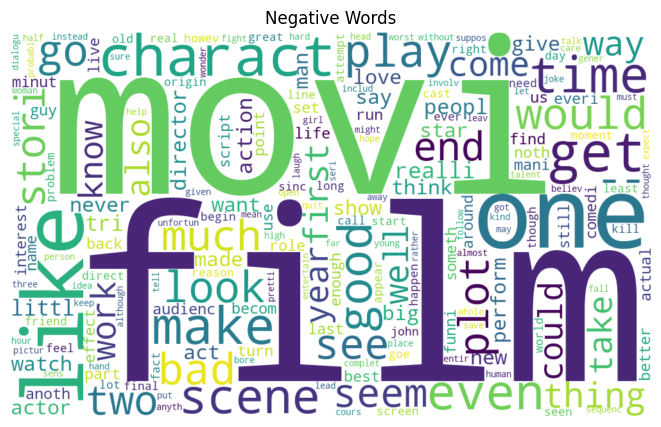

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

def plot_and_save_wordcloud(frequency_dict, title, filename):
    wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        max_words=200,
        colormap="viridis",
    ).generate_from_frequencies(frequency_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    
    # SAVE!
    save_path = os.path.join(project_root, 'images', filename)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Image saved at: {save_path}")
    plt.show()

# Filtering the existing freqs dictionary by labels (1 = positive, 0 = negative)
positive_freqs = {word: freq for (word, label), freq in freqs.items() if label == 1}
negative_freqs = {word: freq for (word, label), freq in freqs.items() if label == 0}

# Run for positive and negative tweets/reviews
plot_and_save_wordcloud(positive_freqs, "Positive Words", "wordcloud_positive.png")
plot_and_save_wordcloud(negative_freqs, "Negative Words", "wordcloud_negative.png")

Image saved at: /Users/aaronluenendonk/movie-sentiment-analysis/images/confusion_matrix.png


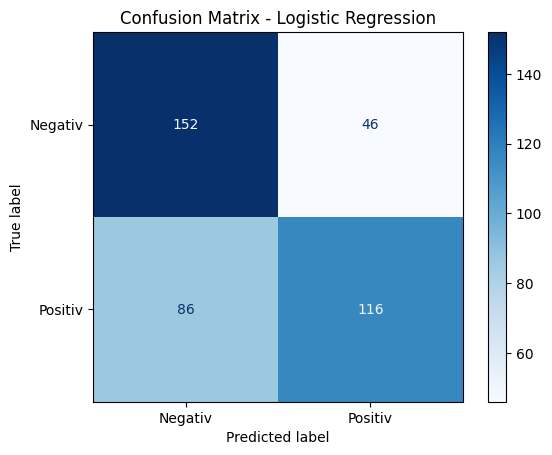

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Coloured matrix of test results
disp = ConfusionMatrixDisplay.from_predictions(
    Y_test, 
    y_pred, 
    display_labels=['Negativ', 'Positiv'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Logistic Regression")

# Save to the images folder
cm_path = os.path.join(project_root, 'images', 'confusion_matrix.png')
plt.savefig(cm_path, bbox_inches='tight', dpi=300)
print(f"Image saved at: {cm_path}")
plt.show()

Image saved at: /Users/aaronluenendonk/movie-sentiment-analysis/images/learning_curve.png


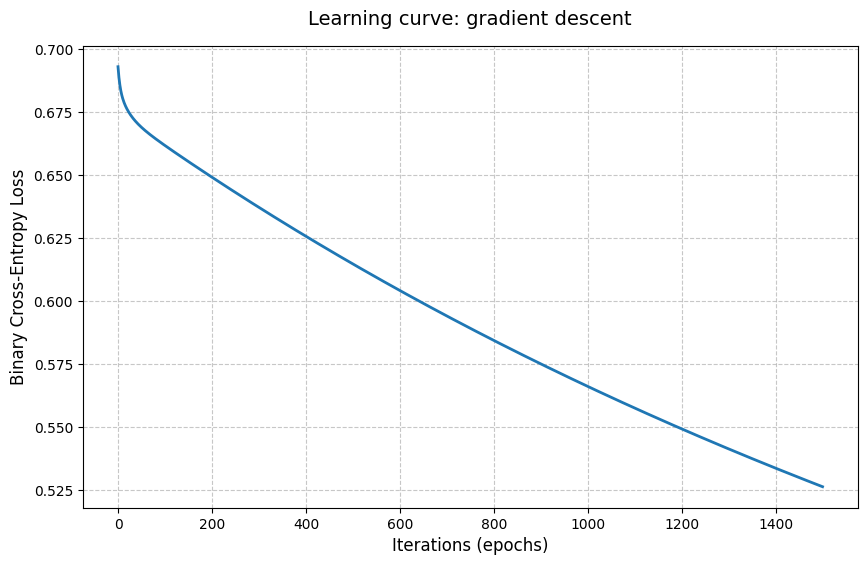

In [4]:
import matplotlib.pyplot as plt
import os

# 1. Plotting a learning curve
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history, color='#1f77b4', linewidth=2)
plt.title("Learning curve: gradient descent", fontsize=14, pad=15)
plt.xlabel("Iterations (epochs)", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Save
loss_path = os.path.join(project_root, 'images', 'learning_curve.png')
plt.savefig(loss_path, bbox_inches='tight', dpi=300)
print(f"Image saved at: {loss_path}")
plt.show()

Image saved at: /Users/aaronluenendonk/movie-sentiment-analysis/images/feature_importance.png


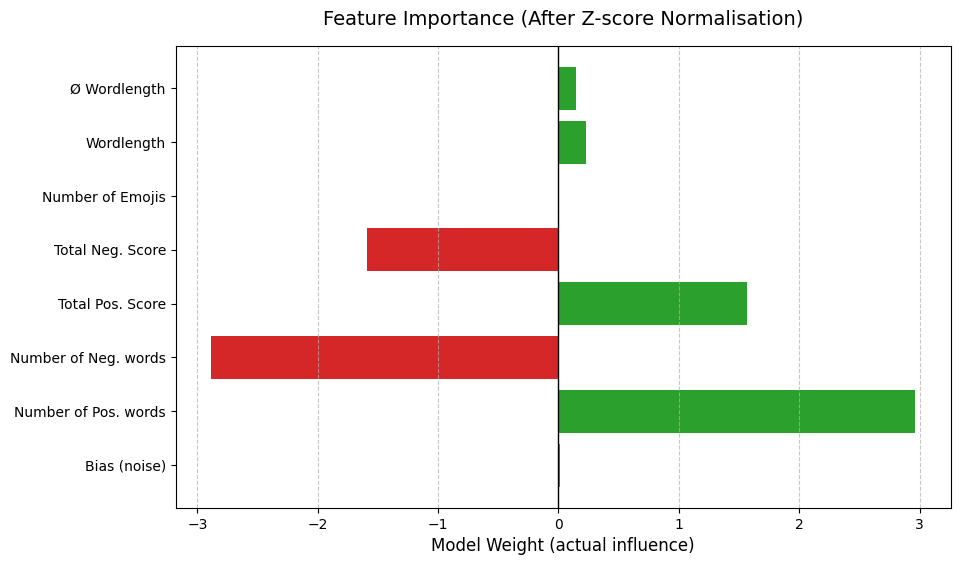

In [8]:
import matplotlib.pyplot as plt
import os

feature_names = [
    'Bias (noise)', 
    'Number of Pos. words', 
    'Number of Neg. words', 
    'Total Pos. Score', 
    'Total Neg. Score', 
    'Number of Emojis', 
    'Wordlength', 
    'Ø Wordlength'
]

# Farben basierend auf dem echten, trainierten Gewicht
colors = ['#2ca02c' if weight > 0 else '#d62728' for weight in trained_weight]

plt.figure(figsize=(10, 6))
plt.barh(feature_names, trained_weight, color=colors)
plt.title("Feature Importance (After Z-score Normalisation)", fontsize=14, pad=15)
plt.xlabel("Model Weight (actual influence)", fontsize=12)
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

importance_path = os.path.join(project_root, 'images', 'feature_importance.png')
plt.savefig(importance_path, bbox_inches='tight', dpi=300)
print(f"Image saved at: {importance_path}")
plt.show()

Image saved at: /Users/aaronluenendonk/movie-sentiment-analysis/images/roc_curve.png


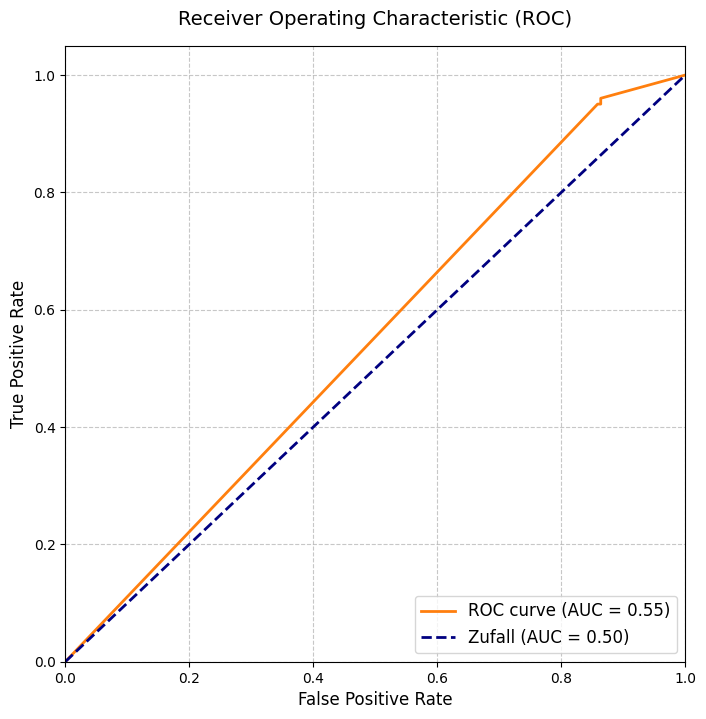

In [6]:
from sklearn.metrics import roc_curve, auc
from src.model import sigmoid
import numpy as np

# 1. Calculating probabilities (without rounding!)
y_proba = sigmoid(np.clip(np.dot(X_test, trained_weight), -500, 500))

# 2. Calculating the false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(Y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='#ff7f0e', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Zufall (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

roc_path = os.path.join(project_root, 'images', 'roc_curve.png')
plt.savefig(roc_path, bbox_inches='tight', dpi=300)
print(f"Image saved at: {roc_path}")
plt.show()